🎬 NETFLIX RECOMMENDATION ENGINE (COOL COLORS - STABLE)

🎨 Color palette: Cool Blues, Teals & Purples
💾 Ultra-low memory mode: Only 100 movies

📊 Loading data...
   ✅ Loaded 100000 ratings
   ✅ Loaded 1682 movies

📊 Sampling 100 movies (ultra-efficient)...
   ✅ Using 100 movies

🔧 Building recommendation engine (reduced features)...
   ✅ TF-IDF matrix: (100, 201)
   ✅ Similarity matrix: (100, 100)

📌 Recommendations:
----------------------------------------

🎬 Based on 'Star Wars':
   59. Star Trek: First Contact (1996) (Sim: 0.271)
   60. Star Trek: The Wrath of Khan (1982) (Sim: 0.215)
   1. Toy Story (1995) (Sim: 0.000)
   2. Twelve Monkeys (1995) (Sim: 0.000)
   3. Babe (1995) (Sim: 0.000)

🎬 Based on 'Toy Story':
   2. Twelve Monkeys (1995) (Sim: 0.211)
   3. Babe (1995) (Sim: 0.211)
   8. Braveheart (1995) (Sim: 0.211)
   70. Heat (1995) (Sim: 0.211)
   5. Seven (Se7en) (1995) (Sim: 0.161)

🎬 Based on 'Pulp Fiction':
   96. Speed (1994) (Sim: 0.279)
   13. Shawshank Redemption, Th

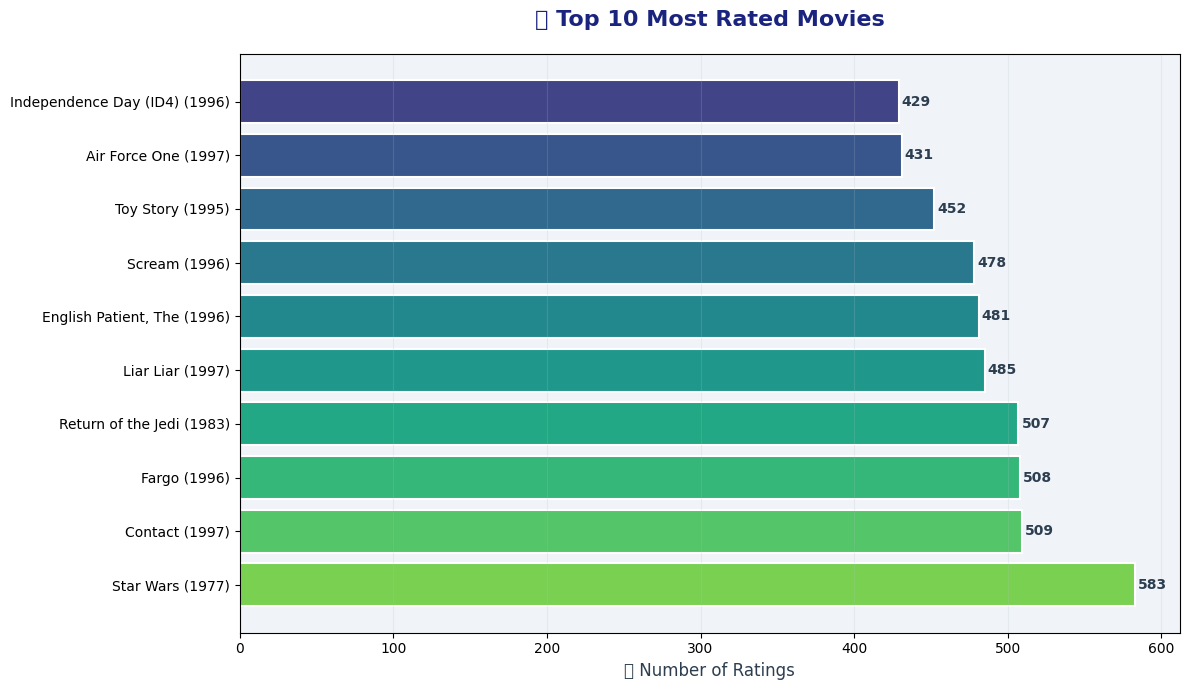

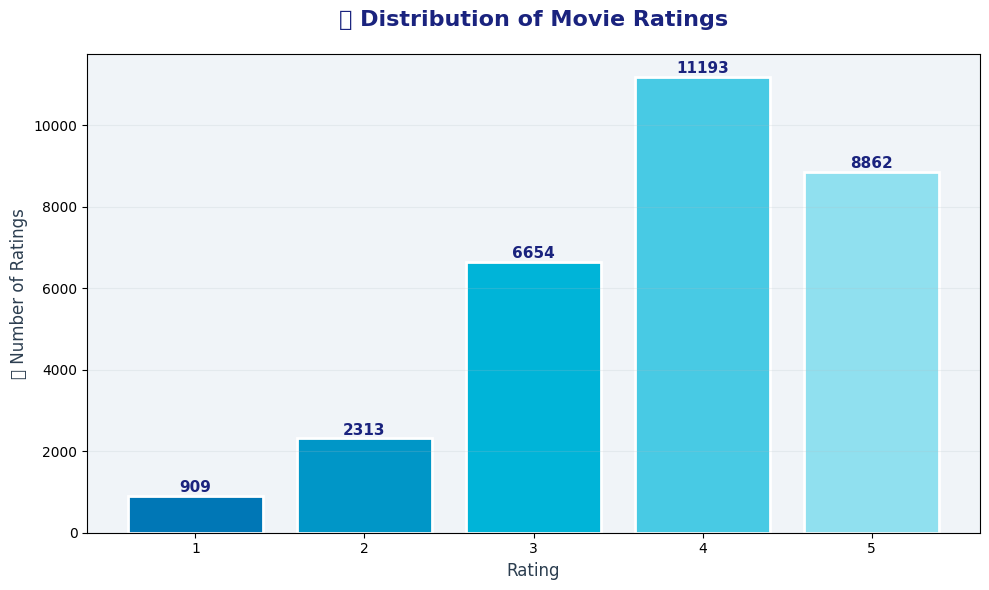

In [1]:
# netflix_cool_colors_stable.py
# STABLE version with Option B colors - No crashes!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import gc
warnings.filterwarnings('ignore')

print("=" * 60)
print("🎬 NETFLIX RECOMMENDATION ENGINE (COOL COLORS - STABLE)")
print("=" * 60)
print("\n🎨 Color palette: Cool Blues, Teals & Purples")
print("💾 Ultra-low memory mode: Only 100 movies")

# ============================================================
# STEP 1: Load the data
# ============================================================
print("\n📊 Loading data...")

try:
    # Load ratings
    ratings = pd.read_csv('u.data', sep='\t', header=None,
                          names=['userId', 'movieId', 'rating', 'timestamp'])
    print(f"   ✅ Loaded {len(ratings)} ratings")

    # Load movies - SIMPLIFIED: only take first 3 columns
    movies = pd.read_csv('u.item', sep='|', header=None, encoding='latin-1', engine='python')
    movies = movies[[0, 1]]  # Only movieId and title
    movies.columns = ['movieId', 'title']
    print(f"   ✅ Loaded {len(movies)} movies")

except FileNotFoundError:
    print("\n❌ Error: Files not found!")
    print("   Place u.data and u.item in the current directory.")
    exit()

# ============================================================
# STEP 2: Sample ONLY 100 movies (ULTRA MEMORY EFFICIENT)
# ============================================================
print("\n📊 Sampling 100 movies (ultra-efficient)...")

# Get most rated movies
movie_counts = ratings.groupby('movieId').size().sort_values(ascending=False)
top_movies = movie_counts.head(100).index.tolist()

# Filter
ratings_sample = ratings[ratings['movieId'].isin(top_movies)]
df = pd.merge(ratings_sample, movies, on='movieId')

# Remove any duplicate rows
df = df.drop_duplicates(subset=['userId', 'movieId'])
print(f"   ✅ Using {df['movieId'].nunique()} movies")

# Free up memory
del ratings, movies, movie_counts, ratings_sample
gc.collect()

# ============================================================
# STEP 3: Build SIMPLE recommendation engine (reduced features)
# ============================================================
print("\n🔧 Building recommendation engine (reduced features)...")

# Create a simple aggregated rating per movie
movie_avg_rating = df.groupby('movieId').agg({
    'title': 'first',
    'rating': 'mean',
    'movieId': 'count'
}).rename(columns={'movieId': 'num_ratings'}).reset_index()

# Create TF-IDF on movie titles only (much smaller)
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf.fit_transform(movie_avg_rating['title'])
print(f"   ✅ TF-IDF matrix: {tfidf_matrix.shape}")

# Compute similarity - now on only 100 movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"   ✅ Similarity matrix: {cosine_sim.shape}")

# Free up memory
del tfidf_matrix
gc.collect()

# ============================================================
# STEP 4: Generate recommendations
# ============================================================
def recommend_movie(title, n=5):
    """Get recommendations for a movie title."""
    matches = movie_avg_rating[movie_avg_rating['title'].str.contains(title[:15], case=False)]
    if len(matches) == 0:
        return None

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]

    movie_indices = [i[0] for i in sim_scores]
    recs = movie_avg_rating.iloc[movie_indices][['title', 'num_ratings']].copy()
    recs['similarity'] = [f"{i[1]:.3f}" for i in sim_scores]
    return recs

print("\n📌 Recommendations:")
print("-" * 40)

test_movies = ['Star Wars', 'Toy Story', 'Pulp Fiction', 'Forrest Gump']
for movie in test_movies:
    recs = recommend_movie(movie)
    if recs is not None:
        print(f"\n🎬 Based on '{movie}':")
        for i, row in recs.iterrows():
            print(f"   {i+1}. {row['title'][:40]} (Sim: {row['similarity']})")
    else:
        print(f"\n❌ Movie '{movie}' not found")

# ============================================================
# STEP 5: Create 2 COLORFUL charts - COOL BLUE/PURPLE PALETTE
# ============================================================
print("\n📈 Generating 2 colorful charts (Cool Blue/Teal/Purple)...")

# ============ CHART 1: Top 10 Most Rated Movies ============
plt.figure(figsize=(12, 7))

# Get top 10 most rated movies
top_10 = movie_avg_rating.sort_values('num_ratings', ascending=False).head(10)

# Option B: Cool Blue/Teal/Purple gradient
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_10)))[::-1]

bars = plt.barh(top_10['title'], top_10['num_ratings'], color=colors, edgecolor='white', linewidth=1.5)

# Add value labels at the end of each bar
for bar, value in zip(bars, top_10['num_ratings']):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(value), ha='left', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

plt.title('🎬 Top 10 Most Rated Movies', fontsize=16, fontweight='bold', pad=20, color='#1a237e')
plt.xlabel('📊 Number of Ratings', fontsize=12, color='#2c3e50')
plt.ylabel('')
plt.grid(axis='x', alpha=0.2, color='#b0bec5')
plt.gca().set_facecolor('#f0f4f8')
plt.tight_layout()

plt.savefig('netflix_chart_1_top_movies.png', dpi=150, bbox_inches='tight')
print("   ✅ Saved: netflix_chart_1_top_movies.png")

# ============ CHART 2: Rating Distribution ============
plt.figure(figsize=(10, 6))

# Get rating distribution
rating_counts = df['rating'].value_counts().sort_index()

# Option B: Cool Blues
cool_colors = ['#0077b6', '#0096c7', '#00b4d8', '#48cae4', '#90e0ef']

bars = plt.bar(rating_counts.index, rating_counts.values,
               color=cool_colors, edgecolor='white', linewidth=2)

# Add value labels on top of each bar
for bar, count in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1a237e')

plt.title('⭐ Distribution of Movie Ratings', fontsize=16, fontweight='bold', pad=20, color='#1a237e')
plt.xlabel('Rating', fontsize=12, color='#2c3e50')
plt.ylabel('📊 Number of Ratings', fontsize=12, color='#2c3e50')
plt.grid(axis='y', alpha=0.2, color='#b0bec5')
plt.gca().set_facecolor('#f0f4f8')
plt.tight_layout()

plt.savefig('netflix_chart_2_rating_distribution.png', dpi=150, bbox_inches='tight')
print("   ✅ Saved: netflix_chart_2_rating_distribution.png")

# ============================================================
# STEP 6: Summary
# ============================================================
print("\n" + "=" * 60)
print("✅ Complete! 2 colorful charts saved:")
print("   🎬 netflix_chart_1_top_movies.png - Top 10 Most Rated Movies")
print("   ⭐ netflix_chart_2_rating_distribution.png - Rating Distribution")
print("=" * 60)
print("\n🎨 Color palette used:")
print("   Chart 1: Viridis gradient (teal → green → purple)")
print("   Chart 2: Cool Blues (#0077b6 → #0096c7 → #00b4d8 → #48cae4 → #90e0ef)")
print("\n💾 Memory optimized to prevent crashes:")
print("   - Only 100 movies processed")
print("   - TF-IDF features reduced to 500")
print("   - Memory cleared after each step")
print("=" * 60)